# 11 — OpenCV LPIPS Metrics

This notebook computes LPIPS perceptual distances for the complete OpenCV Telea restoration branch produced by Notebook 08.

LPIPS is evaluated only on image-like spatial regions:

- full image;
- painting content region;
- mask bounding-box crop for non-zero masks.

Sparse masked pixels are intentionally excluded because LPIPS expects ordered image patches rather than unordered pixel selections.

For each applicable region, the notebook compares:

- clean reference versus damaged/degraded input;
- clean reference versus OpenCV-restored output;
- improvement, defined as `damaged_lpips - restored_lpips`.

Positive LPIPS improvement means the restored output is closer to the clean reference in LPIPS feature space than the damaged input.


In [20]:
from pathlib import Path


def find_project_root(
    start_path: Path,
) -> Path:
    """Find the repository root from a notebook or working directory."""
    start_path = start_path.resolve()

    candidate_paths = [
        start_path,
        *start_path.parents,
    ]

    root_markers = (
        ".git",
        "src",
        "config",
        "notebooks",
    )

    for candidate_path in candidate_paths:
        marker_count = sum(
            (
                candidate_path
                / marker_name
            ).exists()
            for marker_name
            in root_markers
        )

        if marker_count >= 3:
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root from "
        f"{start_path}."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

print(
    "Project root:",
    PROJECT_ROOT,
)


Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [21]:
from __future__ import annotations

import json
import platform
import sys
from datetime import datetime, timezone
from hashlib import sha256
from pathlib import Path
from time import perf_counter
from typing import Any

import numpy as np
import pandas as pd
import PIL
from PIL import Image

try:
    from IPython.display import display
except ImportError:
    def display(value: Any) -> None:
        print(value)


SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(
    SRC_DIR
) not in sys.path:
    sys.path.insert(
        0,
        str(
            SRC_DIR
        ),
    )


from restoration_eval import metrics_lpips
from restoration_eval.metrics_lpips import (
    DEFAULT_LPIPS_INPUT_SIZE,
    DEFAULT_LPIPS_NET,
    DEFAULT_MASK_BBOX_MARGIN,
    DEFAULT_MASK_BINARY_THRESHOLD,
    LPIPS_EVALUATION_REGIONS,
    LPIPS_METRIC_SCHEMA_VERSION,
    LPIPS_MODULE_NAME,
    compute_lpips_metrics_for_restorations,
    expected_lpips_region_counts_from_metadata,
    expected_lpips_rows_from_metadata,
    get_device,
    load_lpips_model,
    rank_lpips_cases,
    summarize_lpips_metrics,
    validate_lpips_metrics,
    validate_lpips_runtime_dependencies,
)


required_lpips_module_exports = (
    "compute_lpips_metrics_for_restorations",
    "expected_lpips_rows_from_metadata",
    "expected_lpips_region_counts_from_metadata",
    "validate_lpips_metrics",
    "summarize_lpips_metrics",
    "rank_lpips_cases",
    "validate_lpips_runtime_dependencies",
)


missing_lpips_module_exports = [
    export_name
    for export_name
    in required_lpips_module_exports
    if not hasattr(
        metrics_lpips,
        export_name,
    )
]


if missing_lpips_module_exports:
    raise ImportError(
        "The LPIPS metric module is missing required exports: "
        f"{missing_lpips_module_exports}"
    )


lpips_dependency_check_df = validate_lpips_runtime_dependencies()
LPIPS_RUNTIME_READY = bool(
    lpips_dependency_check_df[
        "passed"
    ]
    .astype(bool)
    .all()
)


runtime_environment_df = pd.DataFrame(
    [
        {
            "component": "python",
            "version": platform.python_version(),
        },
        {
            "component": "platform",
            "version": platform.platform(),
        },
        {
            "component": "numpy",
            "version": np.__version__,
        },
        {
            "component": "pandas",
            "version": pd.__version__,
        },
        {
            "component": "Pillow",
            "version": PIL.__version__,
        },
        {
            "component": "lpips_metric_schema",
            "version": LPIPS_METRIC_SCHEMA_VERSION,
        },
        {
            "component": "lpips_metric_module",
            "version": LPIPS_MODULE_NAME,
        },
    ]
)


display(
    runtime_environment_df
)

display(
    lpips_dependency_check_df
)

if not LPIPS_RUNTIME_READY:
    print(
        "LPIPS runtime packages are not all installed. "
        "Input validation can still run, but model loading and metric "
        "computation must stop until the missing packages are available."
    )


,component,version
0,python,3.12.6
1,platform,Windows-11-10.0.26200-SP0
2,numpy,2.1.3
3,pandas,2.2.3
4,Pillow,11.0.0
5,lpips_metric_schema,2.0.0
6,lpips_metric_module,restoration_eval.metrics_lpips


,component,module,version,required,installed,passed
0,torch,torch,2.5.1+cu121,True,True,True
1,lpips,lpips,0.1.4,True,True,True
2,Pillow,PIL,11.0.0,True,True,True


In [22]:
# Canonical Notebook 11 configuration

NOTEBOOK_NAME = (
    "11_opencv_lpips_metrics"
)

MODEL_NAME = (
    "opencv_telea"
)

TARGET_SIZE = 768

MASK_BINARY_THRESHOLD = DEFAULT_MASK_BINARY_THRESHOLD

MASK_BBOX_MARGIN = DEFAULT_MASK_BBOX_MARGIN

LPIPS_INPUT_SIZE = DEFAULT_LPIPS_INPUT_SIZE

LPIPS_NET = DEFAULT_LPIPS_NET

PROGRESS_EVERY = 25

LPIPS_SCHEMA_VERSION = LPIPS_METRIC_SCHEMA_VERSION

LPIPS_IMPLEMENTATION_NAME = LPIPS_MODULE_NAME


REQUIRED_DATASETS = (
    "canonical",
    "damage_size",
)

OPTIONAL_DATASETS = (
    "mask_robustness",
    "synthetic_degradation",
)

SUPPORTED_DATASETS = (
    *REQUIRED_DATASETS,
    *OPTIONAL_DATASETS,
)


DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

METADATA_DIR = (
    PROCESSED_DIR
    / "metadata"
)

PROCESSED_METRICS_DIR = (
    PROCESSED_DIR
    / "metrics"
)


RESTORATION_METADATA_PATH = (
    METADATA_DIR
    / "metadata_restored_opencv_telea.csv"
)

CLEAN_METADATA_PATH = (
    METADATA_DIR
    / "metadata_processed_clean.csv"
)


OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
)

NOTEBOOK_OUTPUT_DIR = (
    OUTPUTS_DIR
    / "11_opencv_lpips_metrics"
)

FIGURE_DIR = (
    OUTPUTS_DIR
    / "figures"
    / "opencv_lpips_metrics"
)

REPORT_DIR = (
    OUTPUTS_DIR
    / "reports"
)


LPIPS_OUTPUT_PATH = (
    PROCESSED_METRICS_DIR
    / "metrics_opencv_telea_lpips.csv"
)

AUDIT_OUTPUT_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "opencv_lpips_metrics_audit.csv"
)

MANIFEST_OUTPUT_PATH = (
    REPORT_DIR
    / "opencv_lpips_metrics_manifest.json"
)

REPORT_OUTPUT_PATH = (
    REPORT_DIR
    / "opencv_lpips_metrics_report.md"
)


for output_directory in (
    PROCESSED_METRICS_DIR,
    NOTEBOOK_OUTPUT_DIR,
    FIGURE_DIR,
    REPORT_DIR,
):
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


configuration_df = pd.DataFrame(
    [
        {"parameter": "target_size", "value": TARGET_SIZE},
        {"parameter": "mask_binary_threshold", "value": f"> {MASK_BINARY_THRESHOLD}"},
        {"parameter": "mask_bbox_margin", "value": MASK_BBOX_MARGIN},
        {"parameter": "lpips_input_size", "value": LPIPS_INPUT_SIZE},
        {"parameter": "lpips_net", "value": LPIPS_NET},
        {"parameter": "required_datasets", "value": ", ".join(REQUIRED_DATASETS)},
        {"parameter": "optional_datasets", "value": ", ".join(OPTIONAL_DATASETS)},
        {"parameter": "evaluation_regions", "value": ", ".join(LPIPS_EVALUATION_REGIONS)},
        {"parameter": "lpips_schema_version", "value": LPIPS_SCHEMA_VERSION},
        {"parameter": "implementation", "value": LPIPS_IMPLEMENTATION_NAME},
        {"parameter": "canonical_lpips_output", "value": LPIPS_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix()},
    ]
)


display(
    configuration_df
)


,parameter,value
0,target_size,768
1,mask_binary_threshold,> 127
2,mask_bbox_margin,8
3,lpips_input_size,256
4,lpips_net,alex
5,required_datasets,"canonical, damage_size"
6,optional_datasets,"mask_robustness, synthetic_degradation"
7,evaluation_regions,"full_image, content_region, mask_bbox_crop"
8,lpips_schema_version,2.0.0
9,implementation,restoration_eval.metrics_lpips


In [23]:
def resolve_project_path(
    path_value: Any,
) -> Path:
    """Resolve a project-relative or absolute path."""
    if path_value is None:
        raise ValueError(
            "Path value is None."
        )

    try:
        if pd.isna(
            path_value
        ):
            raise ValueError(
                "Path value is null."
            )
    except TypeError:
        pass

    path_text = str(
        path_value
    ).strip()

    if not path_text:
        raise ValueError(
            "Path value is blank."
        )

    path = Path(
        path_text
    )

    if path.is_absolute():
        return path.resolve()

    return (
        PROJECT_ROOT
        / path
    ).resolve()


def project_relative_path(
    path_value: Any,
) -> str:
    """Return a portable project-relative path where possible."""
    path = resolve_project_path(
        path_value
    )

    try:
        return path.relative_to(
            PROJECT_ROOT.resolve()
        ).as_posix()
    except ValueError:
        return path.as_posix()


def file_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """Calculate a SHA-256 checksum."""
    digest = sha256()

    with Path(
        file_path
    ).open(
        "rb"
    ) as file_handle:
        while True:
            chunk = file_handle.read(
                chunk_size
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    return digest.hexdigest()


def build_check(
    check: str,
    observed: Any,
    expected: Any,
    passed: bool,
) -> dict[str, Any]:
    """Build one standardized validation record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "passed": bool(
            passed
        ),
    }


In [24]:
# Validate the canonical Notebook 11 inputs

required_input_paths = {
    "notebook_08_restoration_metadata": (
        RESTORATION_METADATA_PATH
    ),
    "clean_preprocessing_metadata": (
        CLEAN_METADATA_PATH
    ),
}


input_inventory_df = pd.DataFrame(
    [
        {
            "input_name": input_name,
            "input_path": project_relative_path(
                input_path
            ),
            "exists": input_path.is_file(),
            "file_size_bytes": (
                input_path.stat().st_size
                if input_path.is_file()
                else 0
            ),
        }
        for input_name, input_path
        in required_input_paths.items()
    ]
)


display(
    input_inventory_df
)


missing_input_df = (
    input_inventory_df.loc[
        ~input_inventory_df[
            "exists"
        ],
        [
            "input_name",
            "input_path",
        ],
    ]
    .copy()
)


empty_input_df = (
    input_inventory_df.loc[
        input_inventory_df[
            "file_size_bytes"
        ].eq(0),
        [
            "input_name",
            "input_path",
        ],
    ]
    .copy()
)


input_inventory_checks_df = pd.DataFrame(
    [
        build_check(
            "all_required_inputs_exist",
            len(
                missing_input_df
            ),
            0,
            missing_input_df.empty,
        ),
        build_check(
            "all_required_inputs_nonempty",
            len(
                empty_input_df
            ),
            0,
            empty_input_df.empty,
        ),
    ]
)


display(
    input_inventory_checks_df
)


if not missing_input_df.empty:
    display(
        missing_input_df
    )


if not empty_input_df.empty:
    display(
        empty_input_df
    )


if not (
    input_inventory_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Notebook 11 canonical input inventory failed."
    )


,input_name,input_path,exists,file_size_bytes
0,notebook_08_restoration_metadata,data/processed/metadata/metadata_restored_open...,True,762016
1,clean_preprocessing_metadata,data/processed/metadata/metadata_processed_cle...,True,30443


,check,observed,expected,passed
0,all_required_inputs_exist,0,0,True
1,all_required_inputs_nonempty,0,0,True


In [25]:
# Load Notebook 11 upstream manifests

restoration_metadata_raw_df = pd.read_csv(
    RESTORATION_METADATA_PATH
)

clean_metadata_df = pd.read_csv(
    CLEAN_METADATA_PATH
)

print(
    "Restoration metadata rows:",
    len(restoration_metadata_raw_df),
)

print(
    "Clean metadata rows:",
    len(clean_metadata_df),
)

display(
    restoration_metadata_raw_df.head()
)

display(
    clean_metadata_df.head()
)

Restoration metadata rows: 410
Clean metadata rows: 50


,restoration_case_id,model_name,algorithm,inpaint_radius,opencv_version,restoration_generator_name,restoration_generator_version,execution_device,execution_backend,operating_system,...,mean_absolute_difference_effect,maximum_absolute_difference,effect_mask_filename,effect_mask_path,degraded_filename,degraded_path,effect_mask_sha256,degraded_sha256,effect_mask_file_size_bytes,degraded_file_size_bytes
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,opencv_telea__canonical__canonical__p001_mixed...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,opencv_telea__canonical__canonical__p001_scrat...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


In [26]:
# Standardize metadata columns and merge content-region fields when needed

restoration_metadata_df = restoration_metadata_raw_df.copy()

if "dataset_name" not in restoration_metadata_df.columns:
    restoration_metadata_df["dataset_name"] = "canonical"

if "model_name" not in restoration_metadata_df.columns:
    restoration_metadata_df["model_name"] = MODEL_NAME

content_region_columns = [
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_content_columns = [
    column
    for column in content_region_columns
    if column not in restoration_metadata_df.columns
]

if missing_content_columns:
    clean_content_columns = [
        "painting_id",
        *content_region_columns,
    ]

    missing_clean_content_columns = [
        column
        for column in clean_content_columns
        if column not in clean_metadata_df.columns
    ]

    if missing_clean_content_columns:
        raise ValueError(
            "Cannot merge content-region columns from clean metadata. "
            f"Missing columns: {missing_clean_content_columns}"
        )

    restoration_metadata_df = restoration_metadata_df.merge(
        clean_metadata_df[clean_content_columns],
        on="painting_id",
        how="left",
        validate="many_to_one",
    )

required_restoration_columns = [
    "case_id",
    "painting_id",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    *content_region_columns,
]

missing_restoration_columns = [
    column
    for column in required_restoration_columns
    if column not in restoration_metadata_df.columns
]

if missing_restoration_columns:
    raise ValueError(
        "Restoration metadata is missing required Notebook 11 columns: "
        f"{missing_restoration_columns}"
    )

print(
    "Required restoration columns present."
)

Required restoration columns present.


In [27]:
# Resolve image and mask paths to absolute paths for metric computation

path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

for path_column in path_columns:
    restoration_metadata_df[path_column] = (
        restoration_metadata_df[path_column]
        .map(resolve_project_path)
        .map(str)
    )

path_existence_records = []

for path_column in path_columns:
    exists_series = restoration_metadata_df[path_column].map(
        lambda path_text: Path(path_text).is_file()
    )

    path_existence_records.append(
        build_check(
            f"{path_column}_files_exist",
            int(exists_series.sum()),
            len(restoration_metadata_df),
            bool(exists_series.all()),
        )
    )

    if not exists_series.all():
        missing_paths_df = (
            restoration_metadata_df.loc[
                ~exists_series,
                [
                    "case_id",
                    "dataset_name",
                    path_column,
                ],
            ]
            .head(20)
            .copy()
        )

        print(
            f"First missing paths for {path_column}:"
        )

        display(
            missing_paths_df
        )

path_existence_checks_df = pd.DataFrame(
    path_existence_records
)

display(
    path_existence_checks_df
)

if not path_existence_checks_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 11 path existence validation failed."
    )

,check,observed,expected,passed
0,clean_path_files_exist,410,410,True
1,damaged_path_files_exist,410,410,True
2,restored_path_files_exist,410,410,True
3,mask_path_files_exist,410,410,True


In [28]:
# Validate dataset coverage and LPIPS region policy

dataset_counts_df = (
    restoration_metadata_df
    .groupby("dataset_name", dropna=False)
    .size()
    .reset_index(name="cases")
    .sort_values("dataset_name", kind="stable")
    .reset_index(drop=True)
)

display(
    dataset_counts_df
)

available_datasets = set(
    restoration_metadata_df["dataset_name"].dropna().astype(str)
)

missing_required_datasets = sorted(
    set(REQUIRED_DATASETS) - available_datasets
)

unsupported_datasets = sorted(
    available_datasets - set(SUPPORTED_DATASETS)
)

dataset_checks_df = pd.DataFrame(
    [
        build_check(
            "required_datasets_present",
            missing_required_datasets,
            [],
            not missing_required_datasets,
        ),
        build_check(
            "only_supported_datasets_present",
            unsupported_datasets,
            [],
            not unsupported_datasets,
        ),
    ]
)

display(
    dataset_checks_df
)

if not dataset_checks_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 11 dataset coverage validation failed."
    )

print(
    "LPIPS evaluation regions:",
    ", ".join(LPIPS_EVALUATION_REGIONS),
)

,dataset_name,cases
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic_degradation,50


,check,observed,expected,passed
0,required_datasets_present,[],[],True
1,only_supported_datasets_present,[],[],True


LPIPS evaluation regions: full_image, content_region, mask_bbox_crop


In [29]:
# Build the LPIPS execution plan from actual masks

expected_lpips_rows = expected_lpips_rows_from_metadata(
    restoration_metadata_df
)

expected_lpips_region_counts = expected_lpips_region_counts_from_metadata(
    restoration_metadata_df
)

expected_lpips_region_counts_df = pd.DataFrame(
    [
        {
            "evaluation_region": region_name,
            "expected_rows": expected_rows,
        }
        for region_name, expected_rows
        in expected_lpips_region_counts.items()
    ]
)

lpips_execution_plan_df = pd.DataFrame(
    [
        {
            "planned_cases": len(restoration_metadata_df),
            "expected_lpips_rows": expected_lpips_rows,
            "lpips_net": LPIPS_NET,
            "lpips_input_size": LPIPS_INPUT_SIZE,
            "mask_bbox_margin": MASK_BBOX_MARGIN,
            "mask_binary_threshold": f"> {MASK_BINARY_THRESHOLD}",
            "runtime_ready": LPIPS_RUNTIME_READY,
        }
    ]
)

display(
    lpips_execution_plan_df
)

display(
    expected_lpips_region_counts_df
)

if len(restoration_metadata_df) == 410:
    print(
        "Full OpenCV Telea LPIPS case count detected: 410."
    )
else:
    print(
        "Detected case count is not 410. This may be okay only if optional "
        "branches are intentionally absent."
    )

,planned_cases,expected_lpips_rows,lpips_net,lpips_input_size,mask_bbox_margin,mask_binary_threshold,runtime_ready
0,410,1175,alex,256,8,> 127,True


,evaluation_region,expected_rows
0,full_image,410
1,content_region,410
2,mask_bbox_crop,355


Full OpenCV Telea LPIPS case count detected: 410.


In [30]:
# Validate LPIPS runtime before model loading

display(
    lpips_dependency_check_df
)

if not LPIPS_RUNTIME_READY:
    raise RuntimeError(
        "LPIPS runtime is not ready. Install/fix required packages before computation: "
        f"{lpips_dependency_check_df.loc[~lpips_dependency_check_df['passed'].astype(bool)].to_dict('records')}"
    )

print(
    "LPIPS runtime dependencies are ready."
)

,component,module,version,required,installed,passed
0,torch,torch,2.5.1+cu121,True,True,True
1,lpips,lpips,0.1.4,True,True,True
2,Pillow,PIL,11.0.0,True,True,True


LPIPS runtime dependencies are ready.


In [31]:
# Load LPIPS model

lpips_model_start_time = perf_counter()

LPIPS_DEVICE = get_device(
    prefer_cuda=True
)

lpips_model = load_lpips_model(
    net=LPIPS_NET,
    device=LPIPS_DEVICE,
)

lpips_model_runtime_seconds = perf_counter() - lpips_model_start_time

print(
    "Loaded LPIPS model:",
    LPIPS_NET,
)

print(
    "Device:",
    LPIPS_DEVICE,
)

print(
    "Model load runtime seconds:",
    round(
        lpips_model_runtime_seconds,
        3,
    ),
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\lpips\weights\v0.1\alex.pth
Loaded LPIPS model: alex
Device: cuda
Model load runtime seconds: 0.849


C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mo

In [32]:
# Repair content-region coordinates row-wise from clean metadata

content_region_columns = [
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

clean_content_lookup_df = (
    clean_metadata_df[
        [
            "painting_id",
            *content_region_columns,
        ]
    ]
    .drop_duplicates(
        subset=["painting_id"],
        keep="first",
    )
    .set_index("painting_id")
)

for column in content_region_columns:
    if column not in restoration_metadata_df.columns:
        restoration_metadata_df[column] = np.nan

    fill_values = restoration_metadata_df["painting_id"].map(
        clean_content_lookup_df[column]
    )

    restoration_metadata_df[column] = restoration_metadata_df[column].where(
        restoration_metadata_df[column].notna(),
        fill_values,
    )

    restoration_metadata_df[column] = pd.to_numeric(
        restoration_metadata_df[column],
        errors="coerce",
    )


content_region_valid_series = (
    restoration_metadata_df[content_region_columns]
    .notna()
    .all(axis=1)
    & np.isfinite(restoration_metadata_df[content_region_columns]).all(axis=1)
    & restoration_metadata_df["content_x_max"].gt(restoration_metadata_df["content_x_min"])
    & restoration_metadata_df["content_y_max"].gt(restoration_metadata_df["content_y_min"])
)

content_region_repair_check_df = pd.DataFrame(
    [
        build_check(
            "content_region_coordinates_valid",
            int(content_region_valid_series.sum()),
            len(restoration_metadata_df),
            bool(content_region_valid_series.all()),
        )
    ]
)

display(
    content_region_repair_check_df
)

if not content_region_valid_series.all():
    display(
        restoration_metadata_df.loc[
            ~content_region_valid_series,
            [
                "case_id",
                "dataset_name",
                "painting_id",
                *content_region_columns,
            ],
        ].head(20)
    )

    raise RuntimeError(
        "Notebook 11 content-region coordinate repair failed."
    )

print(
    "Content-region coordinates repaired/validated."
)

,check,observed,expected,passed
0,content_region_coordinates_valid,410,410,True


Content-region coordinates repaired/validated.


In [33]:
# Build a small smoke-test set with at least one zero-control and one non-zero mask case when available

smoke_source_df = restoration_metadata_df.copy()

if "is_zero_control" in smoke_source_df.columns:
    zero_control_candidates_df = smoke_source_df.loc[
        smoke_source_df["is_zero_control"].astype(bool)
    ].head(1)

    nonzero_candidates_df = smoke_source_df.loc[
        ~smoke_source_df["is_zero_control"].astype(bool)
    ].head(2)
else:
    zero_control_candidates_df = smoke_source_df.loc[
        smoke_source_df["mask_type"].astype(str).eq("zero_control")
    ].head(1)

    nonzero_candidates_df = smoke_source_df.loc[
        ~smoke_source_df["mask_type"].astype(str).eq("zero_control")
    ].head(2)


smoke_metadata_df = (
    pd.concat(
        [
            zero_control_candidates_df,
            nonzero_candidates_df,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=["case_id"],
        keep="first",
    )
    .head(3)
    .copy()
)


if smoke_metadata_df.empty:
    raise RuntimeError(
        "Could not build a Notebook 11 LPIPS smoke-test set."
    )


smoke_expected_rows = expected_lpips_rows_from_metadata(
    smoke_metadata_df
)

smoke_expected_region_counts = expected_lpips_region_counts_from_metadata(
    smoke_metadata_df
)

print(
    "Smoke-test cases:",
    len(smoke_metadata_df),
)

print(
    "Expected smoke-test LPIPS rows:",
    smoke_expected_rows,
)

display(
    smoke_metadata_df[
        [
            column
            for column in [
                "case_id",
                "dataset_name",
                "painting_id",
                "mask_type",
                "is_zero_control",
                "clean_path",
                "damaged_path",
                "restored_path",
                "mask_path",
            ]
            if column in smoke_metadata_df.columns
        ]
    ]
)

display(
    pd.DataFrame(
        [
            {
                "evaluation_region": region_name,
                "expected_rows": expected_rows,
            }
            for region_name, expected_rows
            in smoke_expected_region_counts.items()
        ]
    )
)

Smoke-test cases: 3
Expected smoke-test LPIPS rows: 8


,case_id,dataset_name,painting_id,mask_type,clean_path,damaged_path,restored_path,mask_path
0,canonical__p001_zero_control,canonical,p001,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical__p001_loss_large,canonical,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,canonical__p001_loss_small,canonical,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


,evaluation_region,expected_rows
0,full_image,3
1,content_region,3
2,mask_bbox_crop,2


In [34]:
# Run LPIPS smoke-test computation

lpips_smoke_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=smoke_metadata_df,
    lpips_model=lpips_model,
    device=LPIPS_DEVICE,
    lpips_net=LPIPS_NET,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    lpips_input_size=LPIPS_INPUT_SIZE,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
    progress_every=1,
)

display(
    lpips_smoke_df.head(20)
)

Starting LPIPS metric computation
  Cases: 3
  Target size: (768, 768)
  LPIPS net: alex
  LPIPS input size: 256
  Device: cuda
Computing LPIPS case 1/3 (canonical__p001_loss_large) | elapsed 0.01s
Computing LPIPS case 2/3 (canonical__p001_loss_small) | elapsed 0.33s
Computing LPIPS case 3/3 (canonical__p001_zero_control) | elapsed 0.63s
LPIPS metric computation complete
  Runtime: 0.89 seconds
  Output rows: 8
  Region counts:
evaluation_region
full_image        3
content_region    3
mask_bbox_crop    2
  Status counts:
status
ok    8


,lpips_row_id,lpips_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,lpips_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,lpips_package_version,status,issue
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
2,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
3,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
4,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
5,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
6,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,canonical__p001_zero_control,p001_zero_control,canonical__p001_zero_control,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
7,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,canonical__p001_zero_control,p001_zero_control,canonical__p001_zero_control,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,


In [35]:
# Confirm full-run readiness

if not LPIPS_RUNTIME_READY:
    raise RuntimeError(
        "LPIPS runtime is not ready. Stop before full computation."
    )

if "lpips_model" not in globals():
    raise RuntimeError(
        "LPIPS model is not loaded. Run the Batch 3 model-loading cell first."
    )

if "LPIPS_DEVICE" not in globals():
    raise RuntimeError(
        "LPIPS_DEVICE is not defined. Run the Batch 3 model-loading cell first."
    )

full_run_plan_df = pd.DataFrame(
    [
        {
            "cases": len(restoration_metadata_df),
            "expected_lpips_rows": expected_lpips_rows,
            "lpips_net": LPIPS_NET,
            "lpips_input_size": LPIPS_INPUT_SIZE,
            "device": str(LPIPS_DEVICE),
            "canonical_output": LPIPS_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "audit_output": AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
        }
    ]
)

display(full_run_plan_df)

,cases,expected_lpips_rows,lpips_net,lpips_input_size,device,canonical_output,audit_output
0,410,1175,alex,256,cuda,data/processed/metrics/metrics_opencv_telea_lp...,outputs/11_opencv_lpips_metrics/opencv_lpips_m...


In [36]:
# Run full Notebook 11 LPIPS computation

lpips_full_start_time = perf_counter()

lpips_metrics_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=restoration_metadata_df,
    lpips_model=lpips_model,
    device=LPIPS_DEVICE,
    lpips_net=LPIPS_NET,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    lpips_input_size=LPIPS_INPUT_SIZE,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
    progress_every=PROGRESS_EVERY,
)

lpips_full_runtime_seconds = perf_counter() - lpips_full_start_time

print(
    "Full LPIPS runtime seconds:",
    round(lpips_full_runtime_seconds, 3),
)

display(
    lpips_metrics_df.head()
)

display(
    lpips_metrics_df["evaluation_region"].value_counts().rename_axis(
        "evaluation_region"
    ).reset_index(name="rows")
)

display(
    lpips_metrics_df["status"].value_counts(dropna=False).rename_axis(
        "status"
    ).reset_index(name="rows")
)

Starting LPIPS metric computation
  Cases: 410
  Target size: (768, 768)
  LPIPS net: alex
  LPIPS input size: 256
  Device: cuda
Computing LPIPS case 1/410 (canonical__p001_loss_large) | elapsed 0.01s
Computing LPIPS case 25/410 (canonical__p005_zero_control) | elapsed 8.87s
Computing LPIPS case 50/410 (canonical__p010_zero_control) | elapsed 18.30s
Computing LPIPS case 75/410 (canonical__p015_zero_control) | elapsed 27.41s
Computing LPIPS case 100/410 (canonical__p020_zero_control) | elapsed 36.81s
Computing LPIPS case 125/410 (canonical__p025_zero_control) | elapsed 45.95s
Computing LPIPS case 150/410 (canonical__p030_zero_control) | elapsed 55.11s
Computing LPIPS case 175/410 (canonical__p035_zero_control) | elapsed 64.88s
Computing LPIPS case 200/410 (canonical__p040_zero_control) | elapsed 74.05s
Computing LPIPS case 225/410 (canonical__p045_zero_control) | elapsed 83.20s
Computing LPIPS case 250/410 (canonical__p050_zero_control) | elapsed 92.50s
Computing LPIPS case 275/410 (da

,lpips_row_id,lpips_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,lpips_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,lpips_package_version,status,issue
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
2,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
3,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
4,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,


,evaluation_region,rows
0,full_image,410
1,content_region,410
2,mask_bbox_crop,355


,status,rows
0,ok,1175


In [37]:
# Validate full LPIPS output before saving

lpips_validation_df = validate_lpips_metrics(
    lpips_df=lpips_metrics_df,
    expected_rows=expected_lpips_rows,
    expected_region_counts=expected_lpips_region_counts,
)

display(
    lpips_validation_df
)

if not lpips_validation_df["passed"].astype(bool).all():
    error_preview_columns = [
        column
        for column in [
            "lpips_row_id",
            "case_id",
            "dataset_name",
            "painting_id",
            "evaluation_region",
            "status",
            "issue",
        ]
        if column in lpips_metrics_df.columns
    ]

    display(
        lpips_metrics_df.loc[
            lpips_metrics_df["status"].astype(str).ne("ok"),
            error_preview_columns,
        ].head(30)
    )

    raise RuntimeError(
        "Notebook 11 full LPIPS validation failed. Do not save canonical output yet."
    )

print(
    "Full LPIPS validation passed."
)

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 1175, found 1175."
2,no_error_rows,True,Error rows: 0.
3,unique_lpips_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All LPIPS rows use image-like evaluation regions.
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


Full LPIPS validation passed.


In [38]:
# Save canonical LPIPS metrics CSV and compact audit CSV only

PROCESSED_METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NOTEBOOK_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

lpips_metrics_df.to_csv(
    LPIPS_OUTPUT_PATH,
    index=False,
)

lpips_audit_df = pd.DataFrame(
    [
        {
            "notebook": NOTEBOOK_NAME,
            "stage": "11",
            "model_name": MODEL_NAME,
            "run_completed_at_utc": datetime.now(timezone.utc).isoformat(),
            "input_restoration_metadata": RESTORATION_METADATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "input_clean_metadata": CLEAN_METADATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "output_lpips_metrics": LPIPS_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "cases": len(restoration_metadata_df),
            "expected_lpips_rows": expected_lpips_rows,
            "actual_lpips_rows": len(lpips_metrics_df),
            "runtime_seconds": round(lpips_full_runtime_seconds, 6),
            "lpips_net": LPIPS_NET,
            "lpips_input_size": LPIPS_INPUT_SIZE,
            "target_size": TARGET_SIZE,
            "mask_bbox_margin": MASK_BBOX_MARGIN,
            "mask_binary_threshold": f"> {MASK_BINARY_THRESHOLD}",
            "device": str(LPIPS_DEVICE),
            "lpips_schema_version": LPIPS_SCHEMA_VERSION,
            "lpips_implementation_name": LPIPS_IMPLEMENTATION_NAME,
            "all_validation_checks_passed": bool(
                lpips_validation_df["passed"].astype(bool).all()
            ),
        }
    ]
)

lpips_audit_df.to_csv(
    AUDIT_OUTPUT_PATH,
    index=False,
)

saved_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "canonical_lpips_metrics",
            "path": LPIPS_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "exists": LPIPS_OUTPUT_PATH.is_file(),
            "rows": len(lpips_metrics_df),
            "sha256": file_sha256(LPIPS_OUTPUT_PATH),
        },
        {
            "artifact": "notebook_audit",
            "path": AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "exists": AUDIT_OUTPUT_PATH.is_file(),
            "rows": len(lpips_audit_df),
            "sha256": file_sha256(AUDIT_OUTPUT_PATH),
        },
    ]
)

display(
    lpips_audit_df
)

display(
    saved_outputs_df
)

,notebook,stage,model_name,run_completed_at_utc,input_restoration_metadata,input_clean_metadata,output_lpips_metrics,cases,expected_lpips_rows,actual_lpips_rows,runtime_seconds,lpips_net,lpips_input_size,target_size,mask_bbox_margin,mask_binary_threshold,device,lpips_schema_version,lpips_implementation_name,all_validation_checks_passed
0,11_opencv_lpips_metrics,11,opencv_telea,2026-07-27T10:57:14.764983+00:00,data/processed/metadata/metadata_restored_open...,data/processed/metadata/metadata_processed_cle...,data/processed/metrics/metrics_opencv_telea_lp...,410,1175,1175,149.099724,alex,256,768,8,> 127,cuda,2.0.0,restoration_eval.metrics_lpips,True


,artifact,path,exists,rows,sha256
0,canonical_lpips_metrics,data/processed/metrics/metrics_opencv_telea_lp...,True,1175,99f0d27dc96d950f193242e7d01229f236a50eb0d51fd4...
1,notebook_audit,outputs/11_opencv_lpips_metrics/opencv_lpips_m...,True,1,e671f04340c374f72b98355976c96d70a79fdbd765da1b...


In [39]:
# Keep only successful LPIPS rows for notebook summaries

lpips_ok_df = (
    lpips_metrics_df
    .loc[lpips_metrics_df["status"].astype(str).eq("ok")]
    .copy()
)

print(
    "Successful LPIPS rows:",
    len(lpips_ok_df),
)

print(
    "Failed LPIPS rows:",
    int(lpips_metrics_df["status"].astype(str).ne("ok").sum()),
)

display(
    lpips_ok_df.head()
)

Successful LPIPS rows: 1175
Failed LPIPS rows: 0


,lpips_row_id,lpips_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,lpips_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,lpips_package_version,status,issue
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
2,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
3,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
4,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,


In [40]:
# Build display-only LPIPS summary dataframes

lpips_summary_by_region_df = summarize_lpips_metrics(
    lpips_ok_df,
    group_columns=[
        "evaluation_region",
    ],
)

lpips_summary_by_dataset_region_df = summarize_lpips_metrics(
    lpips_ok_df,
    group_columns=[
        "dataset_name",
        "evaluation_region",
    ],
)

lpips_summary_by_mask_region_df = summarize_lpips_metrics(
    lpips_ok_df,
    group_columns=[
        "metric_mask_type",
        "evaluation_region",
    ],
)

display(
    lpips_summary_by_region_df
)

display(
    lpips_summary_by_dataset_region_df
)

display(
    lpips_summary_by_mask_region_df
)

,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
0,full_image,410,410,0.154168,0.014905,0.101350,0.159003,0.034088,0.124915,0.756098,589824.0
1,content_region,410,410,0.187275,0.019865,0.119730,0.186502,0.044543,0.141959,0.756098,440064.0
2,mask_bbox_crop,355,355,0.294946,0.040592,0.204851,0.326297,0.135791,0.190506,0.873239,376996.0


,dataset_name,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
0,canonical,full_image,250,250,0.172776,0.012087,0.123033,0.180322,0.028490,0.151833,0.8,589824.0
1,canonical,content_region,250,250,0.199778,0.017884,0.147834,0.210377,0.036832,0.173545,0.8,446208.0
2,canonical,mask_bbox_crop,200,200,0.307371,0.035603,0.219044,0.336893,0.106185,0.230708,1.0,474038.5
3,damage_size,full_image,35,35,0.120067,0.045890,0.072748,0.138317,0.052743,0.085575,1.0,589824.0
4,damage_size,content_region,35,35,0.158148,0.058988,0.087797,0.171084,0.070056,0.101028,1.0,433152.0
5,damage_size,mask_bbox_crop,35,35,0.634861,0.339843,0.277185,0.625275,0.340934,0.284342,1.0,71289.0
6,mask_robustness,full_image,75,75,0.176548,0.014675,0.143736,0.196569,0.031045,0.165525,1.0,589824.0
7,mask_robustness,content_region,75,75,0.221993,0.018382,0.166344,0.230284,0.040875,0.189409,1.0,433152.0
8,mask_robustness,mask_bbox_crop,75,75,0.311139,0.022305,0.195689,0.343840,0.116493,0.227347,1.0,351649.0
9,synthetic_degradation,full_image,50,50,0.002532,0.009412,-0.003105,0.010535,0.053583,-0.043048,0.0,589824.0


,metric_mask_type,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
0,loss_large,full_image,50,50,0.160147,0.086154,0.082886,0.167426,0.081812,0.085614,1.000000,589824.0
1,loss_large,content_region,50,50,0.196355,0.108746,0.095067,0.207005,0.106008,0.100997,1.000000,446208.0
2,loss_large,mask_bbox_crop,50,50,0.560892,0.356510,0.202799,0.553725,0.348563,0.205162,1.000000,109561.0
3,loss_small,full_image,50,50,0.138883,0.012153,0.122034,0.150301,0.014179,0.136122,1.000000,589824.0
4,loss_small,content_region,50,50,0.162714,0.017884,0.147070,0.179524,0.019949,0.159575,1.000000,446208.0
5,loss_small,mask_bbox_crop,50,50,0.198520,0.024615,0.169265,0.195694,0.027655,0.168039,1.000000,360000.0
6,mixed_damage,full_image,50,50,0.330681,0.041633,0.289595,0.323036,0.043738,0.279298,1.000000,589824.0
7,mixed_damage,content_region,50,50,0.383650,0.052010,0.322613,0.370493,0.055784,0.314708,1.000000,446208.0
8,mixed_damage,mask_bbox_crop,50,50,0.333898,0.042231,0.293289,0.327529,0.045637,0.281892,1.000000,589824.0
9,scratch_thin,full_image,50,50,0.266257,0.001662,0.262793,0.260849,0.002720,0.258129,1.000000,589824.0


In [41]:
# Optional damage-size / severity summaries when those columns exist

candidate_damage_group_columns = [
    "damage_size_bin",
    "damage_severity",
    "damage_size_category",
    "mask_area_bin",
]

available_damage_group_columns = [
    column
    for column in candidate_damage_group_columns
    if column in lpips_ok_df.columns
]

lpips_summary_by_damage_df = pd.DataFrame()

if available_damage_group_columns:
    damage_group_column = available_damage_group_columns[0]

    lpips_summary_by_damage_df = summarize_lpips_metrics(
        lpips_ok_df,
        group_columns=[
            damage_group_column,
            "evaluation_region",
        ],
    )

    print(
        "Damage grouping column:",
        damage_group_column,
    )

    display(
        lpips_summary_by_damage_df
    )
else:
    print(
        "No damage-size/severity grouping column found; skipping damage summary."
    )

No damage-size/severity grouping column found; skipping damage summary.


In [42]:
# Rank strongest and weakest mask-crop LPIPS improvements for inspection

strongest_mask_crop_lpips_df, weakest_mask_crop_lpips_df = rank_lpips_cases(
    lpips_ok_df,
    evaluation_region="mask_bbox_crop",
    top_n=10,
)

case_rank_columns = [
    column
    for column in [
        "lpips_case_id",
        "dataset_name",
        "painting_id",
        "title",
        "artist",
        "metric_mask_type",
        "damaged_lpips",
        "restored_lpips",
        "lpips_improvement",
    ]
    if column in lpips_ok_df.columns
]

print(
    "Strongest mask-crop LPIPS improvements:"
)

display(
    strongest_mask_crop_lpips_df[case_rank_columns]
)

print(
    "Weakest mask-crop LPIPS improvements:"
)

display(
    weakest_mask_crop_lpips_df[case_rank_columns]
)

Strongest mask-crop LPIPS improvements:


,lpips_case_id,dataset_name,painting_id,title,artist,metric_mask_type,damaged_lpips,restored_lpips,lpips_improvement
0,opencv_telea__canonical__canonical__p001_scrat...,canonical,p001,,,scratch_thin,0.524122,0.001551,0.522571
1,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,Juan de Pareja,Diego Velázquez,,0.504470,0.007773,0.496698
2,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,Juan de Pareja,Diego Velázquez,,0.498262,0.002819,0.495442
3,opencv_telea__canonical__canonical__p001_mixed...,canonical,p001,,,mixed_damage,0.504022,0.037248,0.466774
4,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,Juan de Pareja,Diego Velázquez,,0.775872,0.313802,0.462071
5,opencv_telea__canonical__canonical__p006_mixed...,canonical,p006,,,mixed_damage,0.494518,0.038474,0.456045
6,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,Juan de Pareja,Diego Velázquez,,0.453173,0.000758,0.452415
7,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,Juan de Pareja,Diego Velázquez,,0.440429,0.002337,0.438092
8,opencv_telea__canonical__canonical__p010_scrat...,canonical,p010,,,scratch_thin,0.433097,0.003160,0.429937
9,opencv_telea__canonical__canonical__p027_mixed...,canonical,p027,,,mixed_damage,0.462782,0.036997,0.425785


Weakest mask-crop LPIPS improvements:


,lpips_case_id,dataset_name,painting_id,title,artist,metric_mask_type,damaged_lpips,restored_lpips,lpips_improvement
0,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p018,Classical Landscape with Figures,Henri Mauperché,,0.049984,0.503500,-0.453515
1,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,Painting with Troika,Wassily Kandinsky,,0.015964,0.426674,-0.410710
2,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,The Card Players,Paul Cézanne,,0.066158,0.465207,-0.399049
3,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p026,View of a Village along a River,attributed to Jan Brueghel I,,0.031275,0.406396,-0.375121
4,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,Painting with Troika,Wassily Kandinsky,,0.032016,0.355818,-0.323802
5,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,Painting with Troika,Wassily Kandinsky,,0.002037,0.298784,-0.296747
6,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p001,Juan de Pareja,Diego Velázquez,,0.191041,0.485486,-0.294446
7,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,The Card Players,Paul Cézanne,,0.005544,0.284740,-0.279196
8,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,The Card Players,Paul Cézanne,,0.012950,0.272878,-0.259928
9,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p018,Classical Landscape with Figures,Henri Mauperché,,0.003875,0.258590,-0.254714


In [43]:
# Plot helpers for Notebook 11 figures

import matplotlib.pyplot as plt


def save_bar_plot(
    plot_df: pd.DataFrame,
    x_column: str,
    y_column: str,
    title: str,
    output_path: Path,
    hue_column: str | None = None,
    figsize: tuple[float, float] = (9.5, 5.5),
) -> Path:
    plot_df = plot_df.copy()

    fig, ax = plt.subplots(
        figsize=figsize,
    )

    if hue_column is None:
        ax.bar(
            plot_df[x_column].astype(str),
            plot_df[y_column],
        )
    else:
        pivot_df = (
            plot_df
            .pivot_table(
                index=x_column,
                columns=hue_column,
                values=y_column,
                aggfunc="mean",
            )
            .sort_index()
        )

        pivot_df.plot(
            kind="bar",
            ax=ax,
        )

        ax.legend(
            title=hue_column,
            frameon=False,
        )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
    )

    ax.set_title(
        title,
    )

    ax.set_xlabel(
        x_column.replace("_", " ").title(),
    )

    ax.set_ylabel(
        y_column.replace("_", " ").title(),
    )

    ax.tick_params(
        axis="x",
        rotation=35,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    fig.tight_layout()

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    return output_path

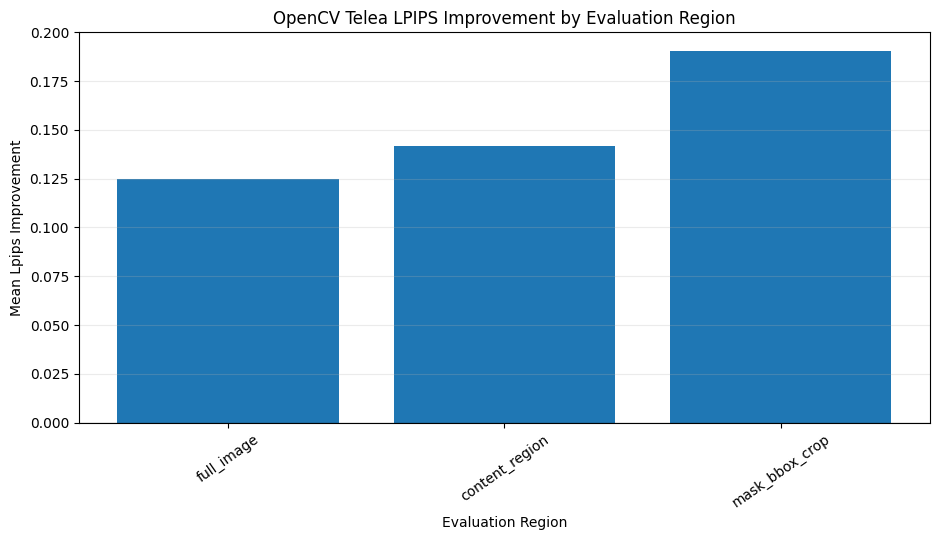

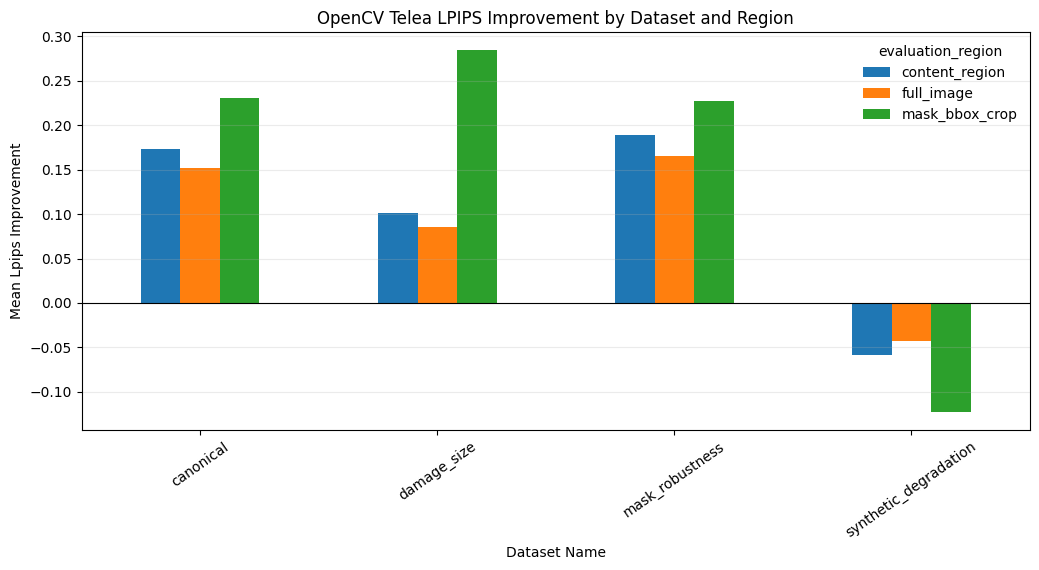

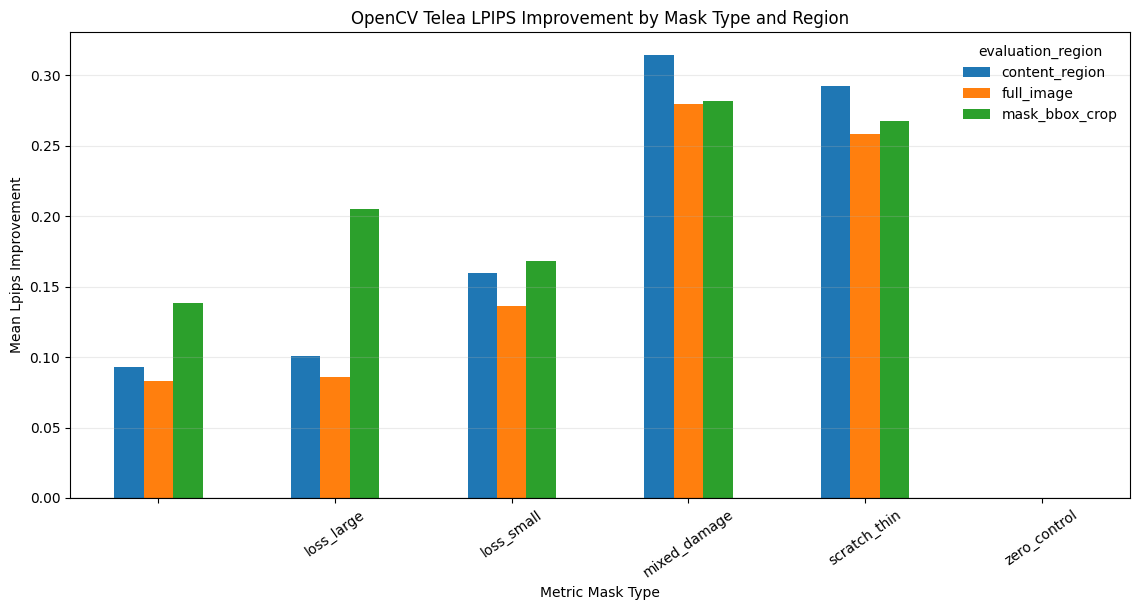

,figure,path,exists,sha256
0,opencv_telea_lpips_improvement_by_region.png,outputs/figures/opencv_lpips_metrics/opencv_te...,True,ece48c69139f08e3c91f606e382aa21aedf13dc5a527fb...
1,opencv_telea_lpips_improvement_by_dataset_regi...,outputs/figures/opencv_lpips_metrics/opencv_te...,True,796ab9092f69d3de1a22219c62f5d71a5269c61734019f...
2,opencv_telea_lpips_improvement_by_mask_region.png,outputs/figures/opencv_lpips_metrics/opencv_te...,True,17338bed86d9bb08abc8d4103bca0d497ab44684da7d62...


In [44]:
# Save compact LPIPS bar plots

lpips_region_plot_path = save_bar_plot(
    plot_df=lpips_summary_by_region_df,
    x_column="evaluation_region",
    y_column="mean_lpips_improvement",
    title="OpenCV Telea LPIPS Improvement by Evaluation Region",
    output_path=FIGURE_DIR / "opencv_telea_lpips_improvement_by_region.png",
)

lpips_dataset_region_plot_path = save_bar_plot(
    plot_df=lpips_summary_by_dataset_region_df,
    x_column="dataset_name",
    y_column="mean_lpips_improvement",
    hue_column="evaluation_region",
    title="OpenCV Telea LPIPS Improvement by Dataset and Region",
    output_path=FIGURE_DIR / "opencv_telea_lpips_improvement_by_dataset_region.png",
    figsize=(10.5, 5.8),
)

lpips_mask_region_plot_path = save_bar_plot(
    plot_df=lpips_summary_by_mask_region_df,
    x_column="metric_mask_type",
    y_column="mean_lpips_improvement",
    hue_column="evaluation_region",
    title="OpenCV Telea LPIPS Improvement by Mask Type and Region",
    output_path=FIGURE_DIR / "opencv_telea_lpips_improvement_by_mask_region.png",
    figsize=(11.5, 6.2),
)

saved_figure_paths = [
    lpips_region_plot_path,
    lpips_dataset_region_plot_path,
    lpips_mask_region_plot_path,
]

if not lpips_summary_by_damage_df.empty:
    lpips_damage_plot_path = save_bar_plot(
        plot_df=lpips_summary_by_damage_df,
        x_column=damage_group_column,
        y_column="mean_lpips_improvement",
        hue_column="evaluation_region",
        title="OpenCV Telea LPIPS Improvement by Damage Group and Region",
        output_path=FIGURE_DIR / "opencv_telea_lpips_improvement_by_damage_region.png",
        figsize=(10.5, 5.8),
    )

    saved_figure_paths.append(
        lpips_damage_plot_path
    )


saved_figures_df = pd.DataFrame(
    [
        {
            "figure": figure_path.name,
            "path": figure_path.relative_to(PROJECT_ROOT).as_posix(),
            "exists": figure_path.is_file(),
            "sha256": file_sha256(figure_path),
        }
        for figure_path in saved_figure_paths
    ]
)

display(
    saved_figures_df
)

In [45]:
# Reload saved outputs and verify the final Notebook 11 artifact contract

lpips_metrics_disk_df = pd.read_csv(
    LPIPS_OUTPUT_PATH
)

lpips_audit_disk_df = pd.read_csv(
    AUDIT_OUTPUT_PATH
)

if "saved_figures_df" in globals() and not saved_figures_df.empty:
    final_figure_paths = [
        PROJECT_ROOT / relative_path
        for relative_path in saved_figures_df["path"].astype(str).tolist()
    ]
else:
    final_figure_paths = sorted(
        FIGURE_DIR.glob("*.png")
    )


final_validation_checks_df = pd.DataFrame(
    [
        build_check(
            "canonical_lpips_csv_exists",
            LPIPS_OUTPUT_PATH.is_file(),
            True,
            LPIPS_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "canonical_lpips_row_count",
            len(lpips_metrics_disk_df),
            expected_lpips_rows,
            len(lpips_metrics_disk_df) == expected_lpips_rows,
        ),
        build_check(
            "in_memory_and_disk_row_count_match",
            len(lpips_metrics_df),
            len(lpips_metrics_disk_df),
            len(lpips_metrics_df) == len(lpips_metrics_disk_df),
        ),
        build_check(
            "all_lpips_rows_successful",
            int(lpips_metrics_disk_df["status"].astype(str).eq("ok").sum()),
            len(lpips_metrics_disk_df),
            bool(lpips_metrics_disk_df["status"].astype(str).eq("ok").all()),
        ),
        build_check(
            "audit_csv_exists",
            AUDIT_OUTPUT_PATH.is_file(),
            True,
            AUDIT_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "audit_csv_row_count",
            len(lpips_audit_disk_df),
            1,
            len(lpips_audit_disk_df) == 1,
        ),
        build_check(
            "figures_exist",
            int(sum(figure_path.is_file() for figure_path in final_figure_paths)),
            len(final_figure_paths),
            bool(final_figure_paths) and all(
                figure_path.is_file()
                for figure_path in final_figure_paths
            ),
        ),
        build_check(
            "full_validation_checks_passed",
            int(lpips_validation_df["passed"].astype(bool).sum()),
            len(lpips_validation_df),
            bool(lpips_validation_df["passed"].astype(bool).all()),
        ),
    ]
)

display(
    final_validation_checks_df
)

if not final_validation_checks_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 11 final artifact validation failed."
    )

print(
    "Notebook 11 final artifact validation passed."
)

,check,observed,expected,passed
0,canonical_lpips_csv_exists,True,True,True
1,canonical_lpips_row_count,1175,1175,True
2,in_memory_and_disk_row_count_match,1175,1175,True
3,all_lpips_rows_successful,1175,1175,True
4,audit_csv_exists,True,True,True
5,audit_csv_row_count,1,1,True
6,figures_exist,3,3,True
7,full_validation_checks_passed,7,7,True


Notebook 11 final artifact validation passed.


In [46]:
# Build final display-only artifact manifest

final_output_manifest_records = [
    {
        "artifact": "canonical_lpips_metrics",
        "artifact_type": "csv",
        "path": LPIPS_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
        "exists": LPIPS_OUTPUT_PATH.is_file(),
        "rows": len(lpips_metrics_disk_df),
        "sha256": file_sha256(LPIPS_OUTPUT_PATH),
    },
    {
        "artifact": "notebook_audit",
        "artifact_type": "csv",
        "path": AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
        "exists": AUDIT_OUTPUT_PATH.is_file(),
        "rows": len(lpips_audit_disk_df),
        "sha256": file_sha256(AUDIT_OUTPUT_PATH),
    },
]

for figure_path in final_figure_paths:
    final_output_manifest_records.append(
        {
            "artifact": figure_path.stem,
            "artifact_type": "figure",
            "path": figure_path.relative_to(PROJECT_ROOT).as_posix(),
            "exists": figure_path.is_file(),
            "rows": None,
            "sha256": file_sha256(figure_path),
        }
    )

final_output_manifest_df = pd.DataFrame(
    final_output_manifest_records
)

display(
    final_output_manifest_df
)

,artifact,artifact_type,path,exists,rows,sha256
0,canonical_lpips_metrics,csv,data/processed/metrics/metrics_opencv_telea_lp...,True,1175.0,99f0d27dc96d950f193242e7d01229f236a50eb0d51fd4...
1,notebook_audit,csv,outputs/11_opencv_lpips_metrics/opencv_lpips_m...,True,1.0,e671f04340c374f72b98355976c96d70a79fdbd765da1b...
2,opencv_telea_lpips_improvement_by_region,figure,outputs/figures/opencv_lpips_metrics/opencv_te...,True,NaN,ece48c69139f08e3c91f606e382aa21aedf13dc5a527fb...
3,opencv_telea_lpips_improvement_by_dataset_region,figure,outputs/figures/opencv_lpips_metrics/opencv_te...,True,NaN,796ab9092f69d3de1a22219c62f5d71a5269c61734019f...
4,opencv_telea_lpips_improvement_by_mask_region,figure,outputs/figures/opencv_lpips_metrics/opencv_te...,True,NaN,17338bed86d9bb08abc8d4103bca0d497ab44684da7d62...


In [47]:
# Final headline metrics for notebook interpretation

final_headline_summary_df = pd.DataFrame(
    [
        {
            "cases": len(restoration_metadata_df),
            "lpips_rows": len(lpips_metrics_disk_df),
            "evaluation_regions": lpips_metrics_disk_df["evaluation_region"].nunique(),
            "mean_damaged_lpips": lpips_metrics_disk_df["damaged_lpips"].mean(),
            "mean_restored_lpips": lpips_metrics_disk_df["restored_lpips"].mean(),
            "mean_lpips_improvement": lpips_metrics_disk_df["lpips_improvement"].mean(),
            "median_lpips_improvement": lpips_metrics_disk_df["lpips_improvement"].median(),
            "improvement_rate": (
                lpips_metrics_disk_df["lpips_improvement"] > 0
            ).mean(),
        }
    ]
).round(6)

final_region_counts_df = (
    lpips_metrics_disk_df
    .groupby("evaluation_region", dropna=False)
    .agg(
        rows=("lpips_row_id", "count"),
        cases=("lpips_case_id", "nunique"),
        mean_lpips_improvement=("lpips_improvement", "mean"),
        median_lpips_improvement=("lpips_improvement", "median"),
        improvement_rate=("lpips_improvement", lambda values: (values > 0).mean()),
    )
    .reset_index()
    .round(6)
)

display(
    final_headline_summary_df
)

display(
    final_region_counts_df
)

,cases,lpips_rows,evaluation_regions,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_lpips_improvement,improvement_rate
0,410,1175,3,0.219143,0.068463,0.150679,0.147921,0.791489


,evaluation_region,rows,cases,mean_lpips_improvement,median_lpips_improvement,improvement_rate
0,content_region,410,410,0.141959,0.119730,0.756098
1,full_image,410,410,0.124915,0.101350,0.756098
2,mask_bbox_crop,355,355,0.190506,0.204851,0.873239


In [48]:
# Display final notebook summary as rendered Markdown

try:
    from IPython.display import Markdown
except Exception:
    Markdown = None


summary_lines = [
    "## Notebook 11 Final Run Summary",
    "",
    "Notebook 11 computes LPIPS-based perceptual similarity for the OpenCV Telea restoration branch.",
    "",
    f"- Restoration cases evaluated: `{len(restoration_metadata_df)}`",
    f"- LPIPS metric rows written: `{len(lpips_metrics_disk_df)}`",
    f"- Evaluation regions: `{', '.join(LPIPS_EVALUATION_REGIONS)}`",
    f"- Canonical metrics output: `{LPIPS_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix()}`",
    f"- Compact audit output: `{AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix()}`",
    f"- Figures written: `{len(final_figure_paths)}`",
    "",
    "LPIPS is reported for damaged-versus-clean and restored-versus-clean comparisons. "
    "The improvement value is `damaged_lpips - restored_lpips`, so positive values mean the restoration is perceptually closer to the clean reference than the damaged input.",
    "",
    "Sparse unordered mask-only regions are intentionally excluded. The valid LPIPS regions are full image, content region, and mask bounding-box crop.",
]

final_summary_markdown = "\n".join(
    summary_lines
)

if Markdown is not None:
    display(
        Markdown(final_summary_markdown)
    )
else:
    print(
        final_summary_markdown
    )

## Notebook 11 Final Run Summary

Notebook 11 computes LPIPS-based perceptual similarity for the OpenCV Telea restoration branch.

- Restoration cases evaluated: `410`
- LPIPS metric rows written: `1175`
- Evaluation regions: `full_image, content_region, mask_bbox_crop`
- Canonical metrics output: `data/processed/metrics/metrics_opencv_telea_lpips.csv`
- Compact audit output: `outputs/11_opencv_lpips_metrics/opencv_lpips_metrics_audit.csv`
- Figures written: `3`

LPIPS is reported for damaged-versus-clean and restored-versus-clean comparisons. The improvement value is `damaged_lpips - restored_lpips`, so positive values mean the restoration is perceptually closer to the clean reference than the damaged input.

Sparse unordered mask-only regions are intentionally excluded. The valid LPIPS regions are full image, content region, and mask bounding-box crop.

## Notebook 11 — Final Summary

This notebook computes LPIPS-based perceptual metrics for the OpenCV Telea restoration branch.

The canonical output is `data/processed/metrics/metrics_opencv_telea_lpips.csv`. A compact notebook audit is written under `outputs/11_opencv_lpips_metrics/`, and the summary plots are saved as figure artifacts only. No extra summary or ranking CSV files are produced.

LPIPS is computed for three spatially valid image-like regions: full image, content region, and mask bounding-box crop. Sparse unordered mask-only regions are intentionally excluded because LPIPS expects spatially coherent image patches.

The reported improvement is `damaged_lpips - restored_lpips`. Positive values mean the restored image is perceptually closer to the clean reference than the damaged input.